# Non-Stationary Dynamics: Global/Local vs Global vs RLS

This notebook compares three ways to handle a **regime-switching** graph
series on a chronological holdout:

1. **Single global** discrete Koopman (`koopman` default)
2. **Architectural global/local** (`koopman="global_local"`) — shared \(K_g\) plus
   a window-conditioned low-rank correction (KNF / Koopa spirit)
3. **Online RLS** on a global operator after the same offline fit
   ([`13_online_adaptation_topology_shock.ipynb`](13_online_adaptation_topology_shock.ipynb))

**Mechanism split.** Global/local is *offline architectural* non-stationarity
(state/window-dependent step). RLS is *online drift* of a fixed-structure \(K\)
after deployment. They are not substitutes; RLS **rejects**
`GlobalLocalKoopmanOperator`. On this seeded chronological holdout, RLS wins and
offline `global_local` need not beat a plain global baseline. Spectrum
vocabulary for state-dependent operators parallels notebook 20
(`auxiliary_spectral`).


## Setup


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import copy
import os
import random

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST") or os.environ.get("CI"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.data import GraphSnapshotSequence
from koopman_graph.datasets.dynamics import (
    diffusion_sequence_from_features,
    laplacian_diffusion_rollout,
)
from koopman_graph.datasets.topology import ring_edge_index
from koopman_graph.operators.global_local import GlobalLocalKoopmanOperator
from koopman_graph.training.pair_objectives import teacher_forced_latent_window

IS_TEST = bool(
    os.environ.get("PYTEST_CURRENT_TEST")
    or os.environ.get("CI")
    or os.environ.get("IS_TEST")
)
SEED = 33
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

N_NODES = 8 if IS_TEST else 16
IN_CHANNELS = 1
LATENT_DIM = 4 if IS_TEST else 8
EPOCHS = 3 if IS_TEST else 50
T_A = 20 if IS_TEST else 40
T_B = 20 if IS_TEST else 40
# Chronological: train covers A + early B; adapt mid-B; holdout late B.
TRAIN_END = T_A + (6 if IS_TEST else 12)
ADAPT_END = T_A + (12 if IS_TEST else 24)
HOLDOUT_START = ADAPT_END
print(
    f"IS_TEST={IS_TEST}  T_A={T_A} T_B={T_B}  "
    f"train<={TRAIN_END} adapt<{ADAPT_END} holdout>={HOLDOUT_START}"
)


IS_TEST=False  T_A=40 T_B=40  train<=52 adapt<64 holdout>=64


## Motivation and background

Non-stationary series break a single fixed \(K\). Two complementary responses:

| Mechanism | Where it lives | What updates |
|-----------|----------------|--------------|
| Global/local | Architecture at train time | \(K_g\) + MLP local correction from a latent window |
| RLS adaptation | Online after fit | Entries of a **dense** \(K\) only (encoder/decoder frozen) |

KNF (Wang et al., ICLR 2023 — `Wang2023KNF`) and Koopa (Liu et al., NeurIPS
2023 — `Liu2023Koopa`) motivate global/local / time-variant Koopman predictors.
KoopmanGraph's `koopman="global_local"` is a discrete, low-rank local
correction — not a full KNF/Koopa reimplementation. Notebook 20's
state-dependent spectrum caveat applies: `matrix` / `spectrum` report \(K_g\)
only.


## Regime-switching synthetic series

Ring Laplacian diffusion with a mid-horizon parameter switch (slow diffusion →
fast diffusion + stronger decay). Same topology; dynamics change.


In [2]:
def regime_switching_diffusion(
    *,
    num_nodes: int,
    t_a: int,
    t_b: int,
    seed: int,
) -> GraphSnapshotSequence:
    edge_index = ring_edge_index(num_nodes)
    gen = torch.Generator().manual_seed(seed)
    feats_a = laplacian_diffusion_rollout(
        edge_index=edge_index,
        num_nodes=num_nodes,
        num_timesteps=t_a,
        in_channels=IN_CHANNELS,
        diffusion_rate=0.15,
        decay_rate=0.99,
        noise_std=0.0,
        initial_state="random",
        dtype=torch.float32,
        generator=gen,
    )
    gen_b = torch.Generator().manual_seed(seed + 1)
    feats_b = laplacian_diffusion_rollout(
        edge_index=edge_index,
        num_nodes=num_nodes,
        num_timesteps=t_b,
        in_channels=IN_CHANNELS,
        diffusion_rate=0.85,
        decay_rate=0.90,
        noise_std=0.0,
        initial_state="random",
        dtype=torch.float32,
        generator=gen_b,
        initial_features=feats_a[-1],
    )
    # Drop duplicate junction snapshot from B's t=0.
    features = torch.cat([feats_a, feats_b[1:]], dim=0)
    return diffusion_sequence_from_features(features, edge_index)


full = regime_switching_diffusion(
    num_nodes=N_NODES, t_a=T_A, t_b=T_B, seed=SEED
)
train_seq = full.slice(0, TRAIN_END)
adapt_seq = full.slice(TRAIN_END, ADAPT_END)
holdout = full.slice(HOLDOUT_START, full.num_timesteps)
print(
    f"full T={full.num_timesteps}  train={train_seq.num_timesteps}  "
    f"adapt={adapt_seq.num_timesteps}  holdout={holdout.num_timesteps}"
)
print(f"regime switch at index {T_A - 1} → {T_A} (0-based)")


full T=79  train=52  adapt=12  holdout=15
regime switch at index 39 → 40 (0-based)


## Minimal example: build matched-capacity models


In [3]:
def make_model(*, kind: str) -> GraphKoopmanModel:
    kwargs = dict(
        encoder=GNNEncoder(IN_CHANNELS, 16, LATENT_DIM, num_layers=2),
        decoder=GNNDecoder(LATENT_DIM, 16, IN_CHANNELS, num_layers=2),
        latent_dim=LATENT_DIM,
        time_step=1.0,
    )
    if kind == "global_local":
        return GraphKoopmanModel(
            **kwargs,
            koopman="global_local",
            koopman_local_window=4 if IS_TEST else 6,
            koopman_local_rank=2,
            koopman_local_hidden_dims=(32,),
        )
    return GraphKoopmanModel(**kwargs)


torch.manual_seed(SEED)
model_global = make_model(kind="global")
torch.manual_seed(SEED)
model_gl = make_model(kind="global_local")
assert isinstance(model_gl.koopman, GlobalLocalKoopmanOperator)

_ = model_global.fit(train_seq, epochs=EPOCHS, lr=1e-3)
_ = model_gl.fit(train_seq, epochs=EPOCHS, lr=1e-3)
print(
    f"fitted global + global_local  epochs={EPOCHS}  "
    f"latent_dim={LATENT_DIM}  (matched encoder/decoder)"
)


fitted global + global_local  epochs=50  latent_dim=8  (matched encoder/decoder)


## Progressive deep dive: RLS adaptation on the global model

Clone the offline global fit, freeze the GNN, and run `adapt_step` through the
adapt window (post-train, pre-holdout). Global/local cannot use RLS.


In [4]:
model_rls = copy.deepcopy(model_global)
model_rls.enable_online_adaptation(forgetting_factor=0.95, regularization=50.0)
model_rls.eval()
for t in range(adapt_seq.num_timesteps - 1):
    _ = model_rls.adapt_step(adapt_seq[t], adapt_seq[t + 1])
print(
    f"RLS adapted over {adapt_seq.num_timesteps - 1} transitions; "
    f"online_adaptation_enabled={model_rls.online_adaptation_enabled}"
)

# Document the hard reject for global/local.
try:
    bad = copy.deepcopy(model_gl)
    bad.enable_online_adaptation()
    print("UNEXPECTED: RLS accepted global_local")
except TypeError as exc:
    print(f"RLS rejects global_local (expected): {exc}")


RLS adapted over 11 transitions; online_adaptation_enabled=True
RLS rejects global_local (expected): RecursiveKoopmanAdapter does not support GlobalLocalKoopmanOperator (state-dependent local correction). Use RLS on a dense per-node or continuous operator, or keep global/local offline.


## Holdout metrics (teacher-forced one-step RMSE)

One-step physical RMSE on the chronological holdout. Global/local uses the
same teacher-forced latent window as training.


In [5]:
def one_step_rmse(model: GraphKoopmanModel, sequence: GraphSnapshotSequence) -> float:
    errs: list[torch.Tensor] = []
    model.eval()
    with torch.no_grad():
        for t in range(sequence.num_timesteps - 1):
            snap = sequence[t]
            z = model.encode(snap)
            lw = teacher_forced_latent_window(model, sequence, t)
            if lw is None:
                z_next = model.koopman.advance(z)
            else:
                z_next = model.koopman.advance(z, latent_window=lw)
            pred = model.decoder(z_next, snap.edge_index)
            target = sequence[t + 1].x
            assert target is not None and pred is not None
            errs.append(torch.mean((pred - target) ** 2))
    return float(torch.sqrt(torch.stack(errs).mean()).item())


metrics = {
    "global": one_step_rmse(model_global, holdout),
    "global_local": one_step_rmse(model_gl, holdout),
    "rls_global": one_step_rmse(model_rls, holdout),
}
# Also score adapt window for context (not the ranking claim).
adapt_metrics = {
    "global": one_step_rmse(model_global, adapt_seq),
    "global_local": one_step_rmse(model_gl, adapt_seq),
    "rls_global": one_step_rmse(model_rls, adapt_seq),
}
print("Holdout one-step RMSE (lower better):")
for name, val in metrics.items():
    print(f"  {name:14s}  {val:.6f}")
print("Adapt-window one-step RMSE (context):")
for name, val in adapt_metrics.items():
    print(f"  {name:14s}  {val:.6f}")


Holdout one-step RMSE (lower better):
  global          0.002966
  global_local    0.004636
  rls_global      0.000136
Adapt-window one-step RMSE (context):
  global          0.001751
  global_local    0.002593
  rls_global      0.000426


## Results

Left panel: chronological **holdout** one-step RMSE (lower is better). On this
seeded run, **RLS on the global model** is lowest by a wide margin; the frozen
**global** baseline is next; **global_local** is highest (worse than plain
global). Right panel: mean feature amplitude decays, with a kink at the dashed
**regime switch** (\(t = T_A\)). That switch sits **inside the train span**;
adapt (pink) and holdout (gray) are entirely in late regime B. Read the bars as
a mechanism split under this split design — not as a universal ranking.


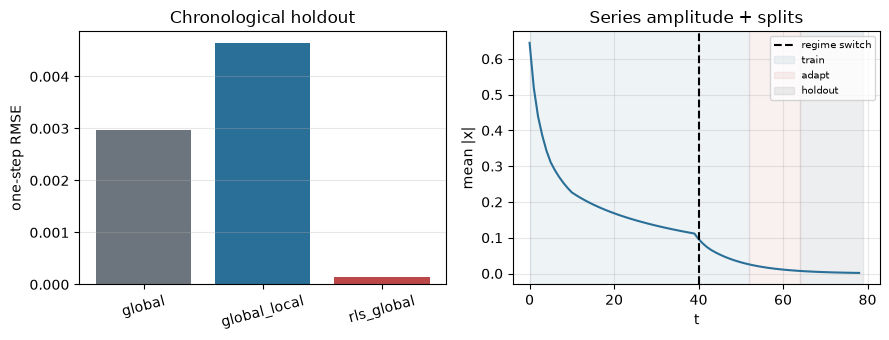

Lowest holdout RMSE: rls_global=0.000136  (seeded teaching result — not a general ranking)


In [6]:
labels = list(metrics.keys())
vals = [metrics[k] for k in labels]
colors = ["#6c757d", "#2a6f97", "#bc4749"]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].bar(labels, vals, color=colors)
axes[0].set_ylabel("one-step RMSE")
axes[0].set_title("Chronological holdout")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.3)

# Mean node feature amplitude over time (regime visual).
amps = [
    float(full[t].x.abs().mean()) for t in range(full.num_timesteps)
]
axes[1].plot(amps, color="#2a6f97", lw=1.5)
axes[1].axvline(T_A, color="k", ls="--", label="regime switch")
axes[1].axvspan(0, TRAIN_END, color="#2a6f97", alpha=0.08, label="train")
axes[1].axvspan(TRAIN_END, ADAPT_END, color="#bc4749", alpha=0.08, label="adapt")
axes[1].axvspan(HOLDOUT_START, full.num_timesteps, color="#6c757d", alpha=0.12, label="holdout")
axes[1].set_xlabel("t")
axes[1].set_ylabel("mean |x|")
axes[1].set_title("Series amplitude + splits")
axes[1].legend(fontsize=7, loc="upper right")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

winner = min(metrics, key=metrics.get)
print(
    f"Lowest holdout RMSE: {winner}={metrics[winner]:.6f}  "
    "(seeded teaching result — not a general ranking)"
)


## Interpretation

On this chronological holdout, **RLS ≪ global < global_local** (one-step RMSE).
That ordering is expected under the mechanism split, not a bake-off:

- **Global** fits one dense \(K\) on train (regime A + early B). Late-B holdout
  pays for that compromise; error is moderate.
- **Global/local** adds offline window-conditioned capacity (`Wang2023KNF` /
  `Liu2023Koopa` spirit). Extra capacity did **not** improve holdout here —
  RMSE rose versus plain global. A mid-train regime switch plus a short early-B
  window can leave the local correction poorly tuned for late B; architectural
  non-stationarity is not a free lunch on chronological RMSE.
- **RLS** alone updates dense \(K\) on the adapt stream (encoder/decoder frozen).
  Coefficients track post-fit drift into late B, which is why holdout RMSE drops
  sharply (same idea as notebook 13). Offline models never see those adapt
  updates — by design.
- Do not combine RLS with `global_local` in the current release (`0.5.0`):
  `RecursiveKoopmanAdapter` rejects `GlobalLocalKoopmanOperator`.
- \(K_g\) / `spectrum` are not certificates for the effective state-dependent
  step (same vocabulary as notebook 20).


## Takeaways

- Reach for RLS (`enable_online_adaptation` / `adapt_step`) when a **deployed
  dense global** model must track post-fit coefficient drift — here it won the
  chronological holdout by a wide margin (notebook 13).
- Treat `koopman="global_local"` as **offline architectural** capacity for
  window-conditioned steps (`Wang2023KNF`, `Liu2023Koopa` spirit), not as a
  substitute for online adaptation — and not as guaranteed lower holdout RMSE.
- **When not:** if the regime switch is mid-train and you only need late-regime
  accuracy, prefer a global fit plus RLS (or retrain on late data) over assuming
  global/local will beat a plain global baseline; this seeded demo had
  `global_local` *worse* than `global`.
- Gotchas: RLS rejects `GlobalLocalKoopmanOperator` (`0.5.0`); match
  encoder/decoder capacity in comparisons; seeded rankings can flip with
  hyperparameters; \(K_g\) / `spectrum` omit the local correction (notebook 20).


## Further reading

- [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html) —
  `GraphKoopmanModel(..., koopman="global_local")`,
  `GlobalLocalKoopmanOperator`, `enable_online_adaptation` / `adapt_step`
- [Architecture](https://koopmangraph.readthedocs.io/en/latest/architecture.html) —
  global/local operator notes and spectrum caveats
- Related notebooks:
  [`13_online_adaptation_topology_shock.ipynb`](13_online_adaptation_topology_shock.ipynb),
  [`20_continuous_spectrum_auxiliary_network.ipynb`](20_continuous_spectrum_auxiliary_network.ipynb)
- Citations (`paper.bib`): `Wang2023KNF`, `Liu2023Koopa`
